# Tutorial 1, worked: Wednesday 7 October

This is the complete Lecture 3 notebook, unchanged, with **every Tutorial 1 exercise worked at the bottom**. Each exercise starts with the economics and a prediction, written down before any code runs; the code then checks the prediction. The Python in each cell is explained line by line in comments.

**Run All first** (it defines `p`, `ages`, `solve_household_grid` and `simulate_profile`), then scroll to *Tutorial 1*.

To use it: copy it into your project's `notebooks/` folder, open it there, choose the `.venv` kernel, Run All. Or open it in Colab from the lectures repository.

# Lecture 3: a household that dies

**ECU44291 Quantitative Macroeconomics, Week 3.**

A household lives $J$ periods, works for the first $J_R$, earns $w e_j$ (an age-efficiency profile), pays a contribution rate $\tau$ on earnings, gets a pension $b$ when retired, saves at gross return $R$, cannot borrow, and starts and ends with nothing:

$$V_j(a) = \max_{0 \le a' \le R a + y_j} \; u(Ra + y_j - a') + \beta V_{j+1}(a'), \qquad V_{J+1} \equiv 0, \qquad u(c) = \frac{c^{1-\sigma}}{1-\sigma}.$$

The terminal condition makes this a **finite algorithm**: solve age $J$, then $J-1$, and so on. No convergence loop. This is the basic form of M1 Part A.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

p = dict(J=60, J_R=45, beta=0.96, R=1.04, sigma=2.0, w=1.0, tau=0.0, repl=0.4, a_max=25.0, n_a=300)
ages = 20 + np.arange(1, p["J"] + 1)

## Task 1: the income profile

Write `efficiency_profile(J, J_R)` returning a hump-shaped $e_j$ (for example $\exp(0.06 j - 0.0012 j^2)$, normalised to mean one over working ages, zero after retirement) and `income_profile(p)` returning $y_j = (1-\tau) w e_j$ while working and a pension equal to `repl` times average gross earnings when retired. Plot it.

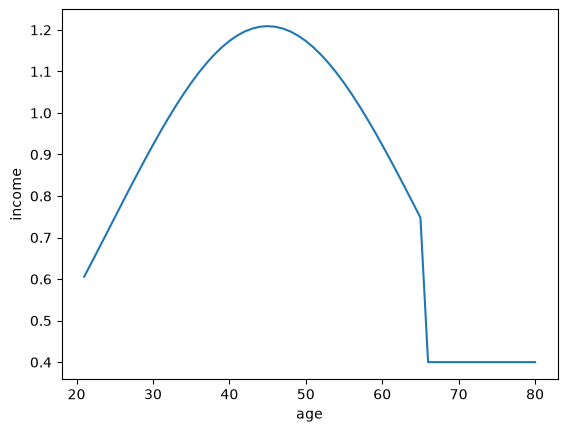

In [2]:
# SOLUTION
def efficiency_profile(J, J_R):
    j = np.arange(1, J + 1)
    e = np.exp(0.06 * j - 0.0012 * j**2)
    e = e / e[:J_R].mean()
    e[J_R:] = 0.0
    return e

def income_profile(p):
    e = efficiency_profile(p["J"], p["J_R"])
    y = (1 - p["tau"]) * p["w"] * e
    y[p["J_R"]:] = p["repl"] * p["w"] * e[:p["J_R"]].mean()
    return y

y = income_profile(p)
plt.plot(ages, y); plt.xlabel("age"); plt.ylabel("income"); plt.show()

## Task 2: backward induction on a grid

Write `solve_household_grid(p)` returning `a_grid`, `V` (shape `(J+1, n_a)`, last row zero) and `policy` (shape `(J, n_a)`, the index of $a'$). Inside the age loop, build the matrix of consumption for every (today's assets, choice) pair, set infeasible entries to $-\infty$, add $\beta V_{j+1}$, and take the max and argmax along the choice axis.

Say out loud, before you run it: which direction does the loop run, and why?

In [3]:
# SOLUTION
def utility(c, sigma):
    return np.log(c) if sigma == 1.0 else c ** (1 - sigma) / (1 - sigma)

def solve_household_grid(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(0.0, p["a_max"], p["n_a"])
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))                  # V[J] = 0 is the terminal condition
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J - 1, -1, -1):                 # last age first
        c = R * a[:, None] + y[j] - a[None, :]     # rows: a today; columns: a' choices
        u = np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

sol = solve_household_grid(p)
print("last-age policy saves nothing:", np.all(sol["policy"][-1] == 0))

last-age policy saves nothing: True


**Workflow note.** *Print statements are a debugger you have to clean up afterwards.* Step through your solver in the VS Code debugger instead:

1. Click in the gutter to the left of the line in your age loop that assigns `V[j]`. A red dot appears.
2. Run the cell that calls `solve_household_grid` with **Debug Cell**: the small arrow next to the cell's Run button, or *Jupyter: Debug Cell* from the Command Palette (Ctrl+Shift+P, Cmd+Shift+P on a Mac). Shift+Enter and the Run button ignore breakpoints: the cell just runs to the end.
3. Execution stops on that line. Look at `j` in the Variables panel: which age is solved first?
4. Press F10 to run the line, then select the text `V[j]` and hover over it (or type `V[j]` in the Debug Console). That row of `n_a` numbers is the value function at one age: a vector, one value per point on the asset grid.
5. Press F5 to go round the loop again, and watch the order in which the rows of `V` fill in. Press Stop on the debug toolbar when you have seen enough.

## Task 3: look at what you solved

Plot $V_j(a)$ for ages 25, 45, 65, 75 on one figure, and the policies $a'(a)$ for the same ages with the 45-degree line. At which ages is $V$ higher, and why is that not a statement about who is better off? (Hint: with $\sigma = 2$, what is the sign of $u(c)$?) Where is $V$ steepest, and what does the slope measure? Why is the policy at 75 below the 45-degree line everywhere?

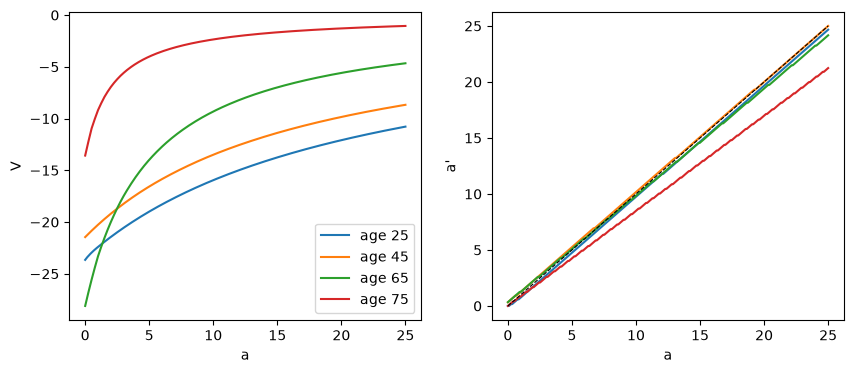

In [4]:
# SOLUTION
a, V, pol = sol["a_grid"], sol["V"], sol["policy"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for j in (4, 24, 44, 54):
    axes[0].plot(a, V[j], label=f"age {20 + j + 1}")
    axes[1].plot(a, a[pol[j]], label=f"age {20 + j + 1}")
axes[1].plot(a, a, "k--", lw=0.8)
axes[0].set_xlabel("a"); axes[0].set_ylabel("V"); axes[0].legend()
axes[1].set_xlabel("a"); axes[1].set_ylabel("a'"); plt.show()

## Task 4: simulate a life

Write `simulate_profile(sol, p)` that starts at zero assets and follows the policy, returning assets (length $J+1$) and consumption (length $J$). Plot consumption against income, and assets by age. Three things to explain: why consumption is flat in the middle of life, why it tracks income early, and why assets peak at retirement.

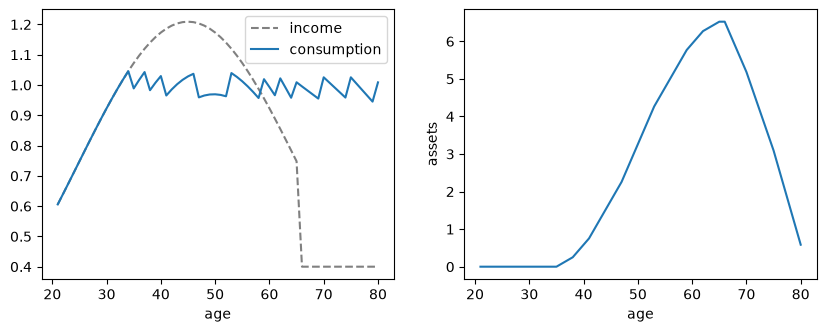

beta * R = 0.9984; peak assets 6.52 at age 65


In [5]:
# SOLUTION
def simulate_profile(sol, p):
    a, pol, y, R = sol["a_grid"], sol["policy"], sol["y"], p["R"]
    idx, assets, cons = 0, [0.0], []
    for j in range(p["J"]):
        nxt = pol[j, idx]
        cons.append(R * a[idx] + y[j] - a[nxt])
        assets.append(a[nxt]); idx = nxt
    return np.array(assets), np.array(cons)

assets, cons = simulate_profile(sol, p)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(ages, sol["y"], "--", color="grey", label="income"); axes[0].plot(ages, cons, label="consumption"); axes[0].legend()
axes[1].plot(ages, assets[:-1]); axes[1].set_ylabel("assets")
for ax in axes: ax.set_xlabel("age")
plt.show()
print(f"beta * R = {p['beta'] * p['R']:.4f}; peak assets {assets.max():.2f} at age {ages[np.argmax(assets[:-1])]}")

## Task 5: a pension contribution

Set $\tau = 0.1$ and re-solve. What happens to consumption while working, to peak assets, and to consumption in retirement (the pension here does not change with $\tau$; in the project it will)?

In [6]:
# SOLUTION
p1 = {**p, "tau": 0.1}
sol1 = solve_household_grid(p1)
assets1, cons1 = simulate_profile(sol1, p1)
print(f"working consumption: {cons[:45].mean():.3f} -> {cons1[:45].mean():.3f}")
print(f"peak assets:         {assets.max():.2f} -> {assets1.max():.2f}")
print(f"retired consumption: {cons[45:].mean():.3f} -> {cons1[45:].mean():.3f}")

working consumption: 0.945 -> 0.855
peak assets:         6.52 -> 5.43
retired consumption: 0.986 -> 0.889


## Task 6: the check

With $J = 2$, log utility, incomes $y_1 = 1$, $y_2 = 0.3$, $R = 1.04$, $\beta = 0.96$, the closed form is $c_1 = (y_1 + y_2/R)/(1+\beta)$ and $s = y_1 - c_1$. Solve the two-period problem on grids of 11, 101, 1001 points and compare the saving you get to the closed form. What is the error proportional to?

In [7]:
# SOLUTION
y1, y2, R, beta = 1.0, 0.3, 1.04, 0.96
c1 = (y1 + y2 / R) / (1 + beta); s_cf = y1 - c1
for n in (11, 101, 1001):
    ag = np.linspace(0, 1, n)
    val = np.full(n, -np.inf); ok = y1 - ag > 0
    val[ok] = np.log(y1 - ag[ok]) + beta * np.log(R * ag[ok] + y2)
    print(f"n = {n:5d}: grid s = {ag[val.argmax()]:.4f}, closed form {s_cf:.4f}, error {abs(ag[val.argmax()] - s_cf):.4f}, spacing {1 / (n - 1):.4f}")

n =    11: grid s = 0.3000, closed form 0.3426, error 0.0426, spacing 0.1000
n =   101: grid s = 0.3400, closed form 0.3426, error 0.0026, spacing 0.0100
n =  1001: grid s = 0.3430, closed form 0.3426, error 0.0004, spacing 0.0010


## Before next week

- This notebook is the skeleton of **M1 Part A**. The solver you tag (`m1-solo`, Friday 23 October) must add something the lecture did not build; the specification on Blackboard says what.
- **M0 is due Friday 2 October, 17:00.** A clean clone that builds, the Solow module with its tests, the golden rule, `AI_LOG.md`, and your commits.
- Read method card 3 (backward induction).
- Workflow note: if you have not yet, step through your Task 2 solver in the VS Code debugger (the note under Task 2). *Print statements are a debugger you have to clean up afterwards.*

# Tutorial 1, worked

Three exercises on the household you solved in Lecture 3. Before the code, the few pieces of Python it uses, in one place:

| You see | It means |
|---|---|
| `q = {**p, "n_a": 30}` | a **new** dictionary: a copy of `p` with one entry changed. `p` itself is untouched, so the lecture's household is always there to compare with. |
| `for n in (30, 100, 300, 1000):` | run the indented lines four times, with `n` set to each number in turn. |
| `sol = solve_household_grid(q)` | solve the household with parameters `q`. `sol` is a dictionary: `sol["a_grid"]`, `sol["V"]`, `sol["policy"]`, `sol["y"]`. |
| `assets, cons = simulate_profile(sol, q)` | follow the policy from zero assets. The function returns two arrays; this line names them. `assets` has 61 entries (assets at the start of each of the 60 ages, plus what is left at death); `cons` has 60. |
| `assets[:-1]` | every entry except the last: assets at the start of each age, so it lines up with `ages`. |
| `x.max()`, `x.argmax()` | the largest value in an array, and its **position** (an index, not a value). `ages[x.argmax()]` turns the position into an age. |
| `cons[20:40]` | entries 20 to 39, which are ages 41 to 60 (age 21 is entry 0). |
| `np.diff(np.log(c))` | the change in log consumption from each age to the next: the growth rate, near enough. |
| `print("peak assets", round(x, 2))` | show the things listed, separated by spaces; `round(x, 2)` is `x` to two decimals. |
| `plt.plot(x, y, label="...")`, then `plt.legend()` | one line on the current figure, then a key naming each line. |

## Exercise 1: the grid

Re-solve with `n_a` = 30, 100, 300 and 1000. Time each solve, record peak assets and the age of the peak, and plot assets by age for all four on one figure.

### The economics first

The household chooses assets tomorrow, $a'$, **from the grid**: `n_a` evenly spaced points from 0 to $\bar a = 25$. So the smallest positive amount it can save is one step of the grid, $25/(n_a - 1)$. If one step is more than the household wants to put away in a year, its only choices are "save nothing" and "save too much", and it may pick nothing.

How much does it want to save? Income peaks at about 1.2 a year. In the lecture (300 points) assets build up to about 6.5 by retirement, over 45 working years, so a typical year's saving is a small fraction of income, about 0.15.

**Prediction:** a grid whose step is close to a year's income will not let this household save at all.

In [8]:
# The step of the grid for each n_a, next to income. No solving yet.
for n in (30, 100, 300, 1000):
    step = p["a_max"] / (n - 1)                      # linspace(0, 25, n) has n - 1 equal gaps
    print("n_a", n, "grid step", round(step, 3))
print("income at its peak", round(income_profile(p).max(), 2))

n_a 30 grid step 0.862
n_a 100 grid step 0.253
n_a 300 grid step 0.084
n_a 1000 grid step 0.025
income at its peak 1.21


With 30 points the step is 0.86, most of a year's income at its peak. With 1000 it is 0.025. Now solve.

In [9]:
import time                                          # for timing; %time in front of a line does the same in a notebook

profiles = {}                                        # an empty dictionary; we keep each grid's assets path in it
for n in (30, 100, 300, 1000):
    q = {**p, "n_a": n}                              # the lecture's parameters with n_a changed
    start = time.perf_counter()                      # clock reading before the solve
    sol_n = solve_household_grid(q)
    seconds = time.perf_counter() - start            # clock reading after, minus before
    assets_n, cons_n = simulate_profile(sol_n, q)
    profiles[n] = assets_n                           # store it under the key n
    peak = assets_n.max()
    peak_age = ages[assets_n[:-1].argmax()] if peak > 0 else "none"
    print("n_a", n, "peak assets", round(peak, 2), "at age", peak_age, "solved in", round(seconds, 2), "seconds")

n_a 30 peak assets 0.0 at age none solved in 0.0 seconds
n_a 100 peak assets 6.06 at age 62 solved in 0.0 seconds
n_a 300 peak assets 6.52 at age 65 solved in 0.01 seconds


n_a 1000 peak assets 6.48 at age 66 solved in 0.68 seconds


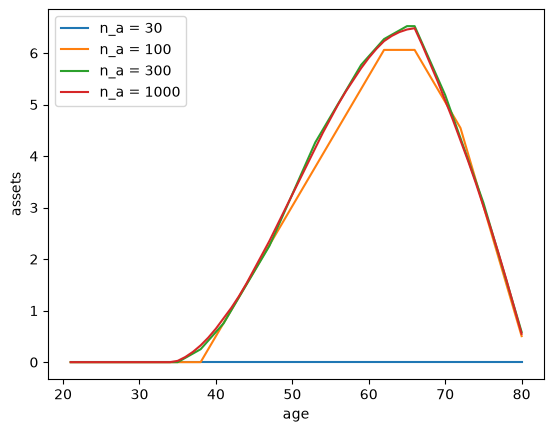

In [10]:
# All four profiles on one figure: one plt.plot per grid, then the key.
for n, assets_n in profiles.items():                 # .items() gives each key with its value
    plt.plot(ages, assets_n[:-1], label=f"n_a = {n}")
plt.xlabel("age"); plt.ylabel("assets"); plt.legend(); plt.show()

### What it shows

- **With 30 points the household never saves.** The smallest positive saving the grid allows is 0.86. Saving nothing and consuming all income beats putting 0.86 away, so it lives hand to mouth all its life and arrives at retirement with nothing. The grid has changed the economics, not only the precision: this is a different household's behaviour, not a blurred picture of the right one.
- **From 300 to 1000 points the answer barely moves** (peak assets 6.52 against 6.48, peak age 65 against 66), but the solve takes many times as long. At every age the solver builds an `n_a` by `n_a` table of consumption, one row per asset level today and one column per choice tomorrow, so the work grows with the **square** of the grid: 3.3 times the points is at least 11 times the work, and in practice more.
- **Which grid?** 300: going to 1000 changes the second decimal of the answer and costs many times the time. The general rule: refine the grid until the answer you care about stops moving, then stop.
- The cost of choosing **on** the grid is why Lecture 5 lets the household choose **between** grid points (continuous choice).

Your times will differ from mine; the ratios will not.

## Exercise 2: patience and smoothing

Re-solve with $\beta \in \{0.90, 0.96, 0.99\}$ and $\sigma \in \{1, 5\}$ ($R = 1.04$ throughout). Plot consumption and assets by age; measure the slope of consumption between ages 41 and 60.

### The economics first

The Euler equation says that at the optimum, moving a little consumption from age $j$ to age $j+1$ neither helps nor hurts:
$$u'(c_j) = \beta R\, u'(c_{j+1}).$$
Giving up one unit today costs $u'(c_j)$; it returns $R$ units tomorrow, each worth $u'(c_{j+1})$, discounted by $\beta$.

With $u(c) = c^{1-\sigma}/(1-\sigma)$, marginal utility is $u'(c) = c^{-\sigma}$, so
$$c_j^{-\sigma} = \beta R\, c_{j+1}^{-\sigma} \quad\Longrightarrow\quad \frac{c_{j+1}}{c_j} = (\beta R)^{1/\sigma}.$$

Read it before computing anything:

- $\beta R > 1$ (patient, or a good return): consumption **rises** with age. $\beta R < 1$: it **falls**. $\beta R = 1$: flat.
- $\sigma$ sits in the exponent as $1/\sigma$: a household with a large $\sigma$ dislikes uneven consumption more, so whatever the direction, its path is **flatter**.
- One caveat: the equation holds only when the household could move consumption both ways. A household that wants to borrow but cannot (assets are at zero) is not on its Euler equation.

**Prediction**, from $(\beta R)^{1/\sigma} - 1$, the growth rate of consumption per year:

In [11]:
# The Euler prediction for each of the six households. Still no solving.
for beta in (0.90, 0.96, 0.99):
    for sigma in (1.0, 5.0):
        betaR = beta * p["R"]
        predicted = betaR ** (1 / sigma) - 1             # (beta R)^(1/sigma) - 1: growth of consumption a year
        print("beta", beta, "sigma", sigma, "beta*R", round(betaR, 3), "predicted growth", round(predicted, 4))

beta 0.9 sigma 1.0 beta*R 0.936 predicted growth -0.064
beta 0.9 sigma 5.0 beta*R 0.936 predicted growth -0.0131
beta 0.96 sigma 1.0 beta*R 0.998 predicted growth -0.0016
beta 0.96 sigma 5.0 beta*R 0.998 predicted growth -0.0003
beta 0.99 sigma 1.0 beta*R 1.03 predicted growth 0.0296
beta 0.99 sigma 5.0 beta*R 1.03 predicted growth 0.0059


So: falling for $\beta = 0.90$, roughly flat for $0.96$, rising for $0.99$, and in each case flatter with $\sigma = 5$ than with $\sigma = 1$. Now solve and measure.

In [12]:
runs = {}                                            # key: (beta, sigma); value: (assets, consumption)
for beta in (0.90, 0.96, 0.99):                      # a loop inside a loop: 3 x 2 = 6 households
    for sigma in (1.0, 5.0):
        q = {**p, "beta": beta, "sigma": sigma}
        sol_q = solve_household_grid(q)
        assets_q, cons_q = simulate_profile(sol_q, q)
        runs[(beta, sigma)] = (assets_q, cons_q)
        slope = np.diff(np.log(cons_q[20:40])).mean()      # average growth of consumption, ages 41 to 60
        predicted = (beta * p["R"]) ** (1 / sigma) - 1
        print("beta", beta, "sigma", sigma, "measured", round(slope, 4), "Euler says", round(predicted, 4),
              "peak assets", round(assets_q.max(), 2))

beta 0.9 sigma 1.0 measured -0.0182 Euler says -0.064 peak assets 0.59
beta 0.9 sigma 5.0 measured -0.0157 Euler says -0.0131 peak assets 3.76
beta 0.96 sigma 1.0 measured -0.0034 Euler says -0.0016 peak assets 6.27
beta 0.96 sigma 5.0 measured 0.0015 Euler says -0.0003 peak assets 6.61
beta 0.99 sigma 1.0 measured 0.028 Euler says 0.0296 peak assets 19.48


beta 0.99 sigma 5.0 measured 0.0075 Euler says 0.0059 peak assets 8.19


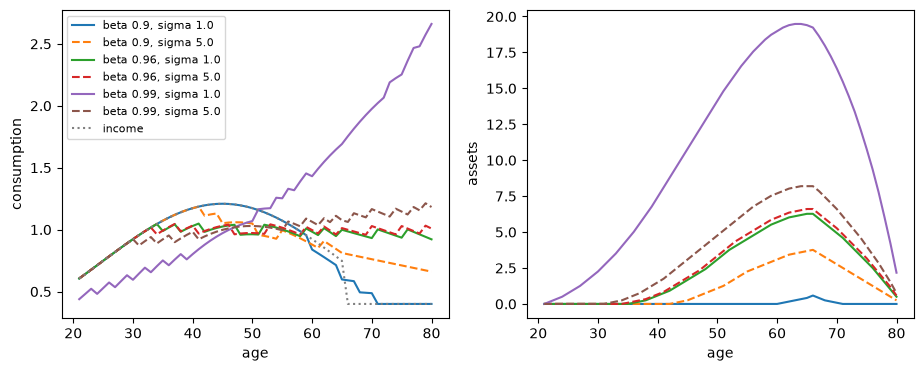

In [13]:
# Two panels side by side: consumption on the left, assets on the right.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))      # axes[0] is the left panel, axes[1] the right
for (beta, sigma), (assets_q, cons_q) in runs.items():
    style = "-" if sigma == 1.0 else "--"            # solid for sigma = 1, dashed for sigma = 5
    axes[0].plot(ages, cons_q, style, label=f"beta {beta}, sigma {sigma}")
    axes[1].plot(ages, assets_q[:-1], style)
axes[0].plot(ages, income_profile(p), ":", color="grey", label="income")
axes[0].set_ylabel("consumption"); axes[1].set_ylabel("assets")
for ax in axes:
    ax.set_xlabel("age")
axes[0].legend(fontsize=8); plt.show()

### Question 3 needs one more look: the impatient household against its income

In [14]:
assets_q, cons_q = runs[(0.90, 1.0)]
y = income_profile(p)
for age in (21, 25, 30, 35, 40):
    j = age - 21                                     # age 21 is entry 0
    print("age", age, "income", round(y[j], 3), "consumption", round(cons_q[j], 3), "assets", round(assets_q[j], 2))

age 21 income 0.606 consumption 0.606 assets 0.0
age 25 income 0.748 consumption 0.748 assets 0.0
age 30 income 0.923 consumption 0.923 assets 0.0
age 35 income 1.072 consumption 1.072 assets 0.0
age 40 income 1.173 consumption 1.173 assets 0.0


### What it shows

1. **Direction.** $\beta = 0.90$: $\beta R = 0.936 < 1$, consumption falls. $\beta = 0.96$: $\beta R = 0.998$, about flat. $\beta = 0.99$: $\beta R = 1.030 > 1$, consumption rises. The Euler equation sets the slope: when waiting pays more than the household's impatience costs, it consumes later.
2. **Prediction against measurement.** Close for $\beta = 0.96$ and $0.99$, within grid noise, and close for $\beta = 0.90$ with $\sigma = 5$.
3. **$\beta = 0.90$ with $\sigma = 1$ disagrees badly**: measured about $-0.018$ a year against a predicted $-0.064$. This household is impatient and its income rises steeply when young, so it wants to **borrow** against later income. The grid starts at zero, so it cannot. Early in life consumption **equals income** and assets are zero: it is at the borrowing constraint, and the Euler equation does not hold there (it holds as $u'(c_j) \ge \beta R\, u'(c_{j+1})$). Its consumption follows its income more than its Euler equation. Peak assets are only 0.59.
4. **$\sigma$ works toward flat consumption, in both directions.** With $\beta R < 1$ the household's impatience tilts consumption down; a larger $\sigma$ fights the tilt, which means saving more (peak assets 0.59 to 3.76 at $\beta = 0.90$). With $\beta R > 1$ the tilt is up; fighting it means saving **less** (19.48 to 8.19 at $\beta = 0.99$). So the asset hump does not move one way with $\sigma$; it moves toward whatever makes consumption flat.

The habit worth keeping: **write the prediction down before you run the code.** When the output agrees, you have checked the code. When it disagrees, as with $\beta = 0.90$, either the code is wrong or the economics has something you left out (here, the borrowing constraint). Both are worth knowing.

## Exercise 3: four broken solvers

Each version of `solve_household_grid` had exactly one line changed. The worked answers are below; **`tutorial01_debrief.ipynb`** (next to this notebook) has each broken solver in full, with its changed line marked, so you can run them and see the output again.

The method for all four is the same, and it is the one the exam asks for: **say what is wrong economically, then find the line that could cause it, then name the check that catches it.**

**Version A.** *Output:* consumption is negative at most ages, with spikes; assets run to the top of the grid and collapse. *Economics:* a household cannot consume a negative amount, so infeasible choices are being allowed. *Line:* `u = np.full(c.shape, -np.inf)` became `u = np.full(c.shape, 0.0)`. With $\sigma = 2$, $u(c) = -1/c$ is negative for every feasible $c$, so an infeasible choice scored at 0 beats every feasible one. That is why the lecture uses `-np.inf`: it can never win an `argmax`; zero can. *Check:* consumption is positive along the simulated path, `(cons > 0).all()`.

**Version B.** *Output:* consumption above income while young, assets negative, and the household **dies owing 5**. *Economics:* nobody lends to someone who dies in debt; the borrowing limit is missing. *Line:* the grid became `np.linspace(-5.0, a_max, n_a)`. Since $V_{J+1} = 0$ whatever the assets, debt at death costs nothing, so the household borrows all the grid allows at the last age. In this solver **the borrowing constraint is the bottom of the grid**. *Check:* assets at death are zero, `assets[-1] == 0`.

**Version C.** *Output:* consumption equals income at every age; assets are zero all life. *Economics:* a household with a hump in its income and a pension below its wage would save; this one never does. *Line:* the loop ran forward, `for j in range(J):`. Each age reads `V[j + 1]` before it has been solved, sees zeros, and eats everything. *Check:* the lecture's last-age check **passes** here, so it is no help. A two-period closed-form check that calls the solver itself catches it.

**Version D.** *Output:* it looks like a household, just not this one: consumption rises about 2% a year in mid-life and peak assets are double the lecture's. *Economics:* the Euler slope gives it away. $(\beta R)^{1/\sigma} - 1 = 0.0198$ when $\beta = 1$ and $R = 1.04$, which is the measured slope. *Line:* $\beta$ is missing: `value = u + V[j + 1][None, :]`. *Check:* the Euler slope against $(\beta R)^{1/\sigma} - 1$, exactly as in Exercise 2.

**The point.** The last-age check caught A and B and missed C and D. A check that passes is not proof that the code is right. Checks that come from the economics (a closed form, the Euler equation, the budget constraint) catch more, which is why M1 asks you to write them as tests.